<a href="https://colab.research.google.com/github/tylerkei9/IntroECG/blob/master/Y_CRNN_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CRNN for ECG Classification — Google Colab

**Before running:**
1. Set runtime to **GPU** (Runtime → Change runtime type → T4 GPU)
2. Upload the three data files to your Google Drive under `MyDrive/echonext_crnn/`:
   - `echonext_metadata_100k.csv`
   - `EchoNext_train_waveforms.npy`
   - `EchoNext_val_waveforms.npy`
3. Run all cells in order

In [1]:
# ── 1. GPU check ──────────────────────────────────────────────────────────────
import torch
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
GPU: NVIDIA H100 80GB HBM3


In [2]:
# ── 2. Install extra packages not pre-installed in Colab ──────────────────────
!pip install -q scikit-image imbalanced-learn

In [3]:
# ── 3. Mount Google Drive ─────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# ── 4. Clone the repo to get CRNN.py and echonext_dataset.py ─────────────────
import os, sys

REPO_DIR = "/content/IntroECG"
CRNN_DIR = os.path.join(REPO_DIR, "4-Models/CRNN-pytorch")

if not os.path.exists(REPO_DIR):
    !git clone https://github.com/tylerkei9/IntroECG.git {REPO_DIR}
else:
    !git -C {REPO_DIR} pull

if CRNN_DIR not in sys.path:
    sys.path.insert(0, CRNN_DIR)

print("CRNN_DIR on path:", CRNN_DIR)

Cloning into '/content/IntroECG'...
remote: Enumerating objects: 386, done.
remote: Counting objects: 100% (109/109), done.
remote: Compressing objects: 100% (70/70), done.
remote: Total 386 (delta 74), reused 48 (delta 39), pack-reused 277 (from 1)
Receiving objects: 100% (386/386), 42.84 MiB | 14.31 MiB/s, done.
Resolving deltas: 100% (181/181), done.
CRNN_DIR on path: /content/IntroECG/4-Models/CRNN-pytorch


In [5]:
# ── 5. Data paths — edit DRIVE_DATA_DIR if you used a different folder name ───
DRIVE_DATA_DIR = "/content/drive/MyDrive/echonext_crnn"

meta_path          = os.path.join(DRIVE_DATA_DIR, "echonext_metadata_100k.csv")
train_waveform_path = os.path.join(DRIVE_DATA_DIR, "EchoNext_train_waveforms.npy")
val_waveform_path   = os.path.join(DRIVE_DATA_DIR, "EchoNext_val_waveforms.npy")

for p in [meta_path, train_waveform_path, val_waveform_path]:
    exists = os.path.exists(p)
    print(f"{'OK' if exists else 'MISSING'}: {p}")
    if not exists:
        raise FileNotFoundError(f"Upload {os.path.basename(p)} to {DRIVE_DATA_DIR}")

OK: /content/drive/MyDrive/echonext_crnn/echonext_metadata_100k.csv
OK: /content/drive/MyDrive/echonext_crnn/EchoNext_train_waveforms.npy
OK: /content/drive/MyDrive/echonext_crnn/EchoNext_val_waveforms.npy


In [6]:
# ── 6. Imports ────────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gc
import warnings
from timeit import default_timer as timer

from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    roc_auc_score, average_precision_score
)

from echonext_dataset import EchoNextWaveformDataset
from CRNN import CRNN

warnings.filterwarnings('ignore', category=FutureWarning)
print("All imports OK")

All imports OK


In [7]:
# ── 7. Load metadata and build datasets ──────────────────────────────────────
meta = pd.read_csv(meta_path)

train_df = meta[meta["split"] == "train"].reset_index(drop=True)
val_df   = meta[meta["split"] == "val"].reset_index(drop=True)

y_train = train_df["shd_moderate_or_greater_flag"].astype("float32").to_numpy(copy=True)
y_val   = val_df["shd_moderate_or_greater_flag"].astype("float32").to_numpy(copy=True)

train_dataset = EchoNextWaveformDataset(train_waveform_path, y_train)
val_dataset   = EchoNextWaveformDataset(val_waveform_path,   y_val)

BATCH_SIZE = 128

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=True)

print("Train samples:", len(train_dataset))
print("Val samples:  ", len(val_dataset))
print("Waveform shape:", train_dataset[0][0].shape)
print("Batch size:", BATCH_SIZE)

Train samples: 72475
Val samples:   4626
Waveform shape: torch.Size([1, 2500, 12])
Batch size: 128


In [8]:
# ── 8. Build model ────────────────────────────────────────────────────────────
try:
    del model
    gc.collect()
    torch.cuda.empty_cache()
except NameError:
    pass

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

model = CRNN(hidR=128 * 2, layerR=1, hidC=128 * 2)
model.to(device)

print(f"Trainable parameters: {sum(p.numel() for p in model.parameters()):,}")

Device: cuda
Trainable parameters: 514,561


In [9]:
# ── 9. Helper functions ───────────────────────────────────────────────────────
def update_outputs(output_dict, new_outputs,
                   outputs_to_update=['scores', 'predictions', 'labels']):
    for x in outputs_to_update:
        if isinstance(new_outputs[x], list):
            output_dict[x] += new_outputs[x]
        else:
            output_dict[x].append(new_outputs[x])
    return output_dict


def accuracy_from_logits(output, target):
    scores = torch.sigmoid(output)
    pred   = torch.round(scores)
    correct = pred.eq(target.data.view_as(pred))
    accuracy = torch.mean(correct.type(torch.FloatTensor))
    return accuracy, scores, pred

In [10]:
# ── 10. Training function ─────────────────────────────────────────────────────
def train(model, device, criterion, optimizer, train_loader, valid_loader,
          save_file_name, scaler=None, max_epochs_stop=5, n_epochs=20, print_every=1):

    use_amp = scaler is not None and torch.cuda.is_available()
    epochs_no_improve = 0
    valid_loss_min    = np.inf
    history           = []

    try:
        print(f'Model has been trained for: {model.epochs} epochs.')
    except AttributeError:
        model.epochs = 0
        print('Starting training from scratch.')

    overall_start = timer()

    for epoch in range(n_epochs):
        model.train()
        train_loss = train_acc = 0.0
        train_steps = 0
        train_out = {"scores": [], "predictions": [], "labels": []}
        start = timer()

        for ii, (inputs, targets) in enumerate(train_loader):
            train_steps += 1
            inputs  = inputs.to(device, dtype=torch.float32)
            targets = targets.to(device, dtype=torch.float32)

            optimizer.zero_grad()

            with torch.cuda.amp.autocast(enabled=use_amp):
                output = model(inputs)
                assert output.shape == targets.shape
                loss = criterion(output, targets)

            if use_amp:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                loss.backward()
                optimizer.step()

            train_loss += loss.item()
            acc, scores, pred = accuracy_from_logits(output, targets)
            train_acc += acc.item()

            train_out = update_outputs(train_out, {
                "predictions": pred.detach().cpu().numpy().squeeze().tolist(),
                "scores":      scores.detach().cpu().numpy().squeeze().tolist(),
                "labels":      targets.detach().cpu().numpy().squeeze().tolist()
            })

            print(f'Epoch {epoch}  {100*(ii+1)/len(train_loader):.1f}%  '
                  f'{timer()-start:.1f}s elapsed', end='\r')

        train_loss /= train_steps
        train_acc  /= train_steps
        model.epochs += 1

        val_loss = val_acc = 0.0
        val_steps = 0
        val_out = {"scores": [], "predictions": [], "labels": []}

        with torch.no_grad():
            model.eval()
            for inputs, targets in valid_loader:
                val_steps += 1
                inputs  = inputs.to(device, dtype=torch.float32)
                targets = targets.to(device, dtype=torch.float32)

                with torch.cuda.amp.autocast(enabled=use_amp):
                    output = model(inputs)
                    loss   = criterion(output, targets)

                val_loss += loss.item()
                acc, scores, pred = accuracy_from_logits(output, targets)
                val_acc += acc.item()

                val_out = update_outputs(val_out, {
                    "predictions": pred.detach().cpu().numpy().squeeze().tolist(),
                    "scores":      scores.detach().cpu().numpy().squeeze().tolist(),
                    "labels":      targets.detach().cpu().numpy().squeeze().tolist()
                })

        val_loss /= val_steps
        val_acc  /= val_steps

        roc     = roc_auc_score(val_out["labels"],   val_out["scores"])
        roc_tr  = roc_auc_score(train_out["labels"], train_out["scores"])
        history.append([train_loss, val_loss, train_acc, val_acc, roc_tr, roc])

        if (epoch + 1) % print_every == 0:
            prec, rec, f1, _ = precision_recall_fscore_support(
                val_out["labels"], val_out["predictions"])
            print(f'\n--- Epoch {epoch} ---')
            print(f'  Train loss: {train_loss:.4f}  Val loss: {val_loss:.4f}')
            print(f'  Train acc:  {100*train_acc:.2f}%  Val acc: {100*val_acc:.2f}%')
            print(f'  Train ROC: {roc_tr:.4f}  Val ROC: {roc:.4f}')
            for j in range(len(prec)):
                print(f'  Class {j}  P:{100*prec[j]:.1f}%  R:{100*rec[j]:.1f}%  F1:{100*f1[j]:.1f}%')

        if val_loss < valid_loss_min:
            torch.save(model.state_dict(), save_file_name)
            epochs_no_improve = 0
            valid_loss_min    = val_loss
            best_epoch        = epoch
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= max_epochs_stop:
            print(f'Early stopping at epoch {epoch}')
            break

    total = timer() - overall_start
    print(f'\nBest epoch: {best_epoch}  val_loss: {valid_loss_min:.4f}')
    print(f'Total time: {total:.1f}s')

    history = pd.DataFrame(history,
        columns=['train_loss','valid_loss','train_acc','valid_acc','train_roc','roc'])
    return model, history

In [11]:
# ── 11. Criterion, optimizer, hyperparameters ─────────────────────────────────
criterion   = nn.BCEWithLogitsLoss().to(device)
optimizer   = optim.Adam(model.parameters(), weight_decay=0.001)
NUM_EPOCHS  = 20
SAVE_PATH   = "/content/drive/MyDrive/echonext_crnn/crnn_best.pt"
BATCH_SIZE  = 128  # bump from 64 — T4 has 16GB, model is small

# Mixed precision scaler (no-op if on CPU)
scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())
print("AMP enabled:", torch.cuda.is_available())

AMP enabled: True


In [12]:
# ── 12. Train ─────────────────────────────────────────────────────────────────
model, history = train(
    model, device, criterion, optimizer,
    train_loader, val_loader,
    save_file_name=SAVE_PATH,
    scaler=scaler,
    max_epochs_stop=4,
    n_epochs=NUM_EPOCHS,
    print_every=1
)

Starting training from scratch.

--- Epoch 0 ---
  Train loss: 0.6486  Val loss: 0.5496
  Train acc:  61.15%  Val acc: 72.26%
  Train ROC: 0.6603  Val ROC: 0.7868
  Class 0  P:72.9%  R:82.5%  F1:77.4%
  Class 1  P:71.9%  R:59.3%  F1:65.0%

--- Epoch 1 ---
  Train loss: 0.5604  Val loss: 0.6185
  Train acc:  71.44%  Val acc: 67.15%
  Train ROC: 0.7828  Val ROC: 0.7870
  Class 0  P:80.4%  R:56.6%  F1:66.4%
  Class 1  P:58.7%  R:81.8%  F1:68.3%

--- Epoch 2 ---
  Train loss: 0.5534  Val loss: 0.8413
  Train acc:  71.82%  Val acc: 47.19%
  Train ROC: 0.7896  Val ROC: 0.7764
  Class 0  P:93.5%  R:8.2%  F1:15.1%
  Class 1  P:44.9%  R:99.2%  F1:61.9%

--- Epoch 3 ---
  Train loss: 0.5502  Val loss: 0.6045
  Train acc:  72.02%  Val acc: 70.91%
  Train ROC: 0.7916  Val ROC: 0.7891
  Class 0  P:77.6%  R:69.1%  F1:73.1%
  Class 1  P:64.3%  R:73.5%  F1:68.6%

--- Epoch 4 ---
  Train loss: 0.5505  Val loss: 0.6070
  Train acc:  72.09%  Val acc: 68.91%
  Train ROC: 0.7918  Val ROC: 0.7982
  Class 0 

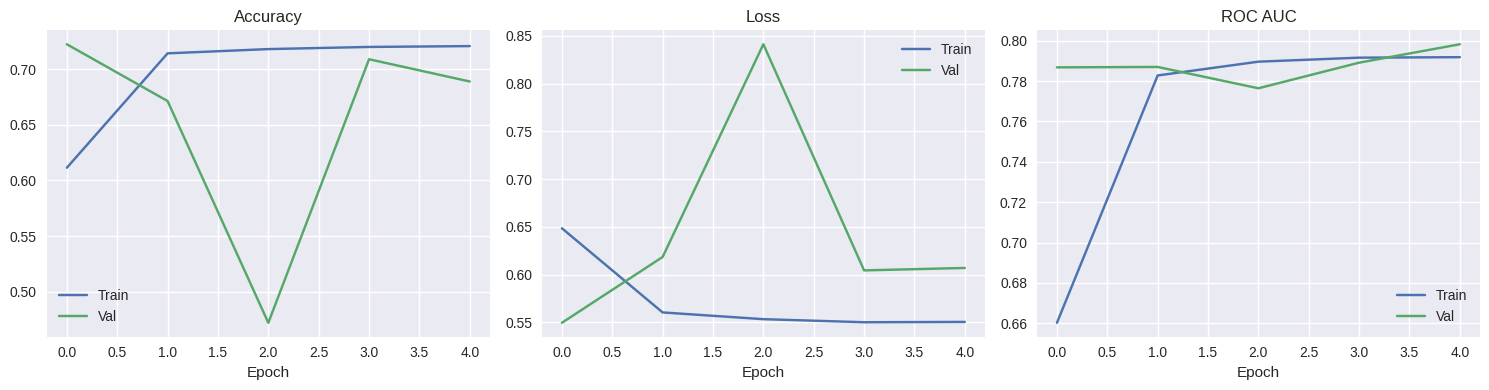

Best Val ROC AUC : 0.7982
Best Val Accuracy: 0.7226
Best epoch:
train_loss    0.550514
valid_loss    0.607018
train_acc     0.720942
valid_acc     0.689072
train_roc     0.791828
roc           0.798221
Name: 4, dtype: float64


In [13]:
# ── 13. Plot results ──────────────────────────────────────────────────────────
plt.style.use('seaborn-v0_8')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

epochs = range(len(history))

axes[0].plot(epochs, history['train_acc'],   label='Train')
axes[0].plot(epochs, history['valid_acc'],   label='Val')
axes[0].set_title('Accuracy'); axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot(epochs, history['train_loss'],  label='Train')
axes[1].plot(epochs, history['valid_loss'],  label='Val')
axes[1].set_title('Loss'); axes[1].set_xlabel('Epoch'); axes[1].legend()

axes[2].plot(epochs, history['train_roc'],   label='Train')
axes[2].plot(epochs, history['roc'],         label='Val')
axes[2].set_title('ROC AUC'); axes[2].set_xlabel('Epoch'); axes[2].legend()

plt.tight_layout()
plt.show()

print(f"Best Val ROC AUC : {history['roc'].max():.4f}")
print(f"Best Val Accuracy: {history['valid_acc'].max():.4f}")
print("Best epoch:")
print(history.loc[history['roc'].idxmax()])

In [14]:
# ── Evaluate on test set ──────────────────────────────────────────────────────
import torch
from sklearn.metrics import (accuracy_score, roc_auc_score,
                             average_precision_score,
                             precision_recall_fscore_support)

# Load best saved weights
model.load_state_dict(torch.load(SAVE_PATH, map_location=device))
model.eval()

test_out = {"scores": [], "predictions": [], "labels": []}

with torch.no_grad():
    for inputs, targets in val_loader:  # swap in test_loader if you have a separate test split
        inputs  = inputs.to(device, dtype=torch.float32)
        targets = targets.to(device, dtype=torch.float32)
        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            output = model(inputs)
        scores = torch.sigmoid(output)
        preds  = torch.round(scores)
        test_out["scores"]      += scores.cpu().numpy().tolist()
        test_out["predictions"] += preds.cpu().numpy().tolist()
        test_out["labels"]      += targets.cpu().numpy().tolist()

prec, rec, f1, _ = precision_recall_fscore_support(test_out["labels"], test_out["predictions"])

print(f"Accuracy : {accuracy_score(test_out['labels'], test_out['predictions']):.4f}")
print(f"ROC AUC  : {roc_auc_score(test_out['labels'], test_out['scores']):.4f}")
print(f"AUPRC    : {average_precision_score(test_out['labels'], test_out['scores']):.4f}")
for j in range(len(prec)):
    print(f"Class {j}  Precision: {100*prec[j]:.2f}%  Recall: {100*rec[j]:.2f}%  F1: {100*f1[j]:.2f}%")

Accuracy : 0.7252
ROC AUC  : 0.7868
AUPRC    : 0.7500
Class 0  Precision: 72.88%  Recall: 82.47%  F1: 77.38%
Class 1  Precision: 71.88%  Recall: 59.35%  F1: 65.02%
